# Proyecto 1 - Parte 1

## Pedro Pablo Sanín Trujillo - 202221527

## Parte 1 - Importación de librerías y preprocesamiento de los textos.

Primero explicaremos el funcionamiento del procesamiento en un documento individual y luego construiremos el pipeline para aplicar las transformaciones al conjunto de datos. Inicialmente, haremos el preprocesamiento de los textos del conjunto de entrenamiento. Luego, tokenizaremos el texto para dividirlo en palabras individuales. Finalmente, hacemos stemming para que las palabras con la misma raíz sean consideradas como la misma palabra. Note que, en general, no nos interesan las terminaciones de las palabras. Por ejemplo, en el contexto del problema, las palabras: compra, compras y compramos nos transmiten básicamente la misma información. Tomar estas palabras como diferentes hace que los modelos sean innecesariamente pesados y complicados.


- Tokenización: Usaremos ``word_tokenize`` de ``NLTK``.
- Stemming: Usaremos ``SnowballStemmer`` de ``NLTK`` con el idioma fijado en ``spanish``.



In [75]:
# Importación de librerías
import nltk
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nltk.download('punkt_tab')  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download('stopwords')  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()


Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [77]:
data.describe(include=['object'])


/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_54541/2899086016.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [78]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Vemos que en este caso, no tenemos datos faltantes inválidos, además, el número de datos de cada categoría es mas o menos igual. Por lo que podemos proceder directamente a la tokenización y stemming. 

Luego identificamos las `stop words` en español presentes en el texto. Estas son palabras que no agregan significado al texto, como y, de, un, entre otras. 

Para procesar estas palabras, usamos ``stopwords`` de ``nltk.corpus`` Al final, construimos una función ``tokenizer_stemmer`` para aplicar la tokenización, stemming y eliminación de stopwords.

In [79]:
spanish_stopwords = set(stopwords.words("spanish"))
stemmer = SnowballStemmer("spanish")


def tokenizer_stemmer(text, stopwords=spanish_stopwords):
    """Hacemos el preprocesamiento del texto: tokenización y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    return [
        stemmer.stem(t)
        for t in word_tokenize(text.lower())
        if t.isalpha() and t not in stopwords
    ]

In [80]:
ejemplo = "Este es un ejemplo de texto para tokenización y stemming."
tokenizer_stemmer(ejemplo)

['ejempl', 'text', 'tokeniz', 'stemming']

## Parte 2 - Construcción del pipeline de preprocesamiento

A continuación, debemos construir una representación de nuestro texto que sea matemáticamente comprensible para nuestros modelos. Para hacer eso, usamos una representación en matrices dispersas. Para este propósito ``sk-learn`` ofrece varias formas de convertir nuestro texto en matrices dispersas.

- CountVectorizer: Produce una matriz dispersa 


In [ ]:
TEXT_COLUMN = 'text'
TARGET_COLUMN = 'label'

VECTORIZERS = {
    'count': CountVectorizer,
    'tfidf': TfidfVectorizer,
}


def build_preprocessor(vectorizer='count'):
    """Construye el preprocesador de las features (texto) con el vectorizador indicado: 'count' o 'tfidf'."""
    return ColumnTransformer([
        ('vectorizer', VECTORIZERS[vectorizer](tokenizer=tokenizer_stemmer, token_pattern=None), TEXT_COLUMN),
    ])


preprocessor = build_preprocessor('tfidf')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('vectorizer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [ ]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ambos se ajustan solo con train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")



X - Train: (9600, 2770) | Test: (2400, 2770)
y - Train: (9600, 3) | Test: (2400, 3)
Clases: ['negativo' 'neutral' 'positivo']


In [83]:
vectorizer = preprocessor.named_transformers_['vectorizer']

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

vocabulary = pd.DataFrame(vectorizer.vocabulary_.items(), columns=['term', 'index'])
vocabulary

Vocabulary size: 2770


,term,index
0,compr,534
1,hac,1268
2,par,1841
3,mes,1618
4,internet,1400
...,...,...
2765,windows,2766
2766,despacit,812
2767,callcul,366
2768,aarr,4


## Entrenamiento del modelo

Accuracy: 0.7120833333333333
              precision    recall  f1-score   support

    negativo       0.60      0.58      0.59       843
     neutral       0.96      0.99      0.97       715
    positivo       0.60      0.60      0.60       842

    accuracy                           0.71      2400
   macro avg       0.72      0.73      0.72      2400
weighted avg       0.71      0.71      0.71      2400



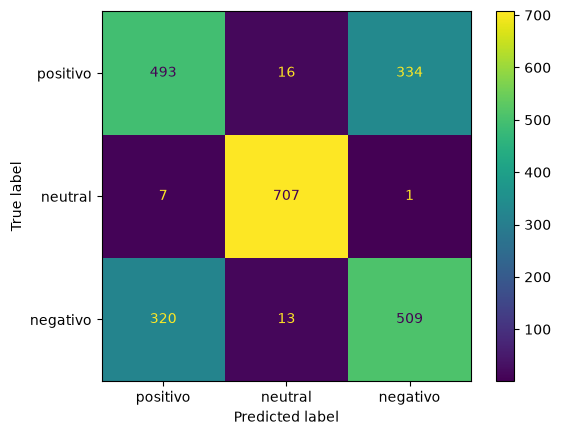

In [87]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['positivo', 'neutral','negativo'])
plt.show()
